In [13]:
import os
while not os.path.isdir('.git'):
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

# Carrier amplitude

## 1000 Hz carrier

In [44]:
carriers = [1000, 2000, 5000, 9000]
offset = 5

In [45]:
carrier_amplitude = 1000

In [85]:
def lowpass_filter(signal, fs, cutoff=200, order=4):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='high')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal
    # return (filtered_signal - np.mean(filtered_signal)) / np.std(np.abs(filtered_signal)) + np.mean(signal)

from scipy.signal import firwin, lfilter

def lowpass_fir_filter(signal, fs, cutoff=200, numtaps=101):
    nyq = 0.5 * fs
    if cutoff >= nyq:
        raise ValueError("Cutoff must be less than Nyquist frequency.")
    taps = firwin(numtaps, cutoff / nyq)
    return lfilter(taps, 1.0, signal)

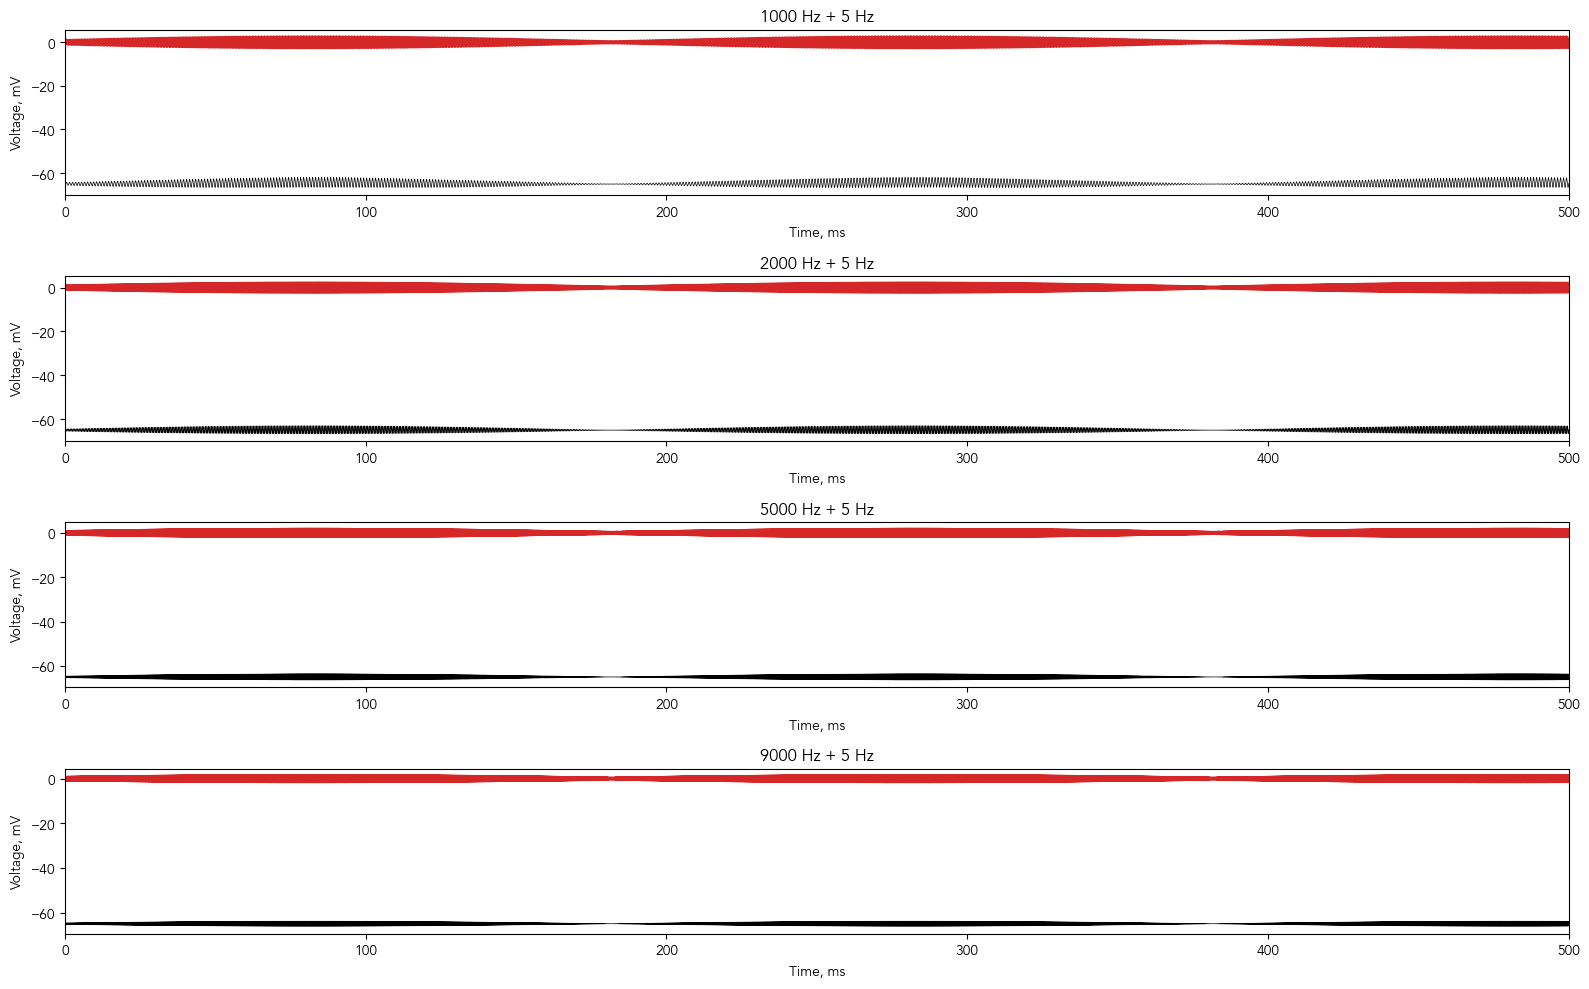

In [86]:
fig, axs = plt.subplots(nrows = len(carriers), ncols = 1, figsize = (16, 2.5 * len(carriers)))
axs = axs.flatten()

for carrier, ax in zip(carriers, axs):
    voltage = pd.read_csv(f"output/temporal-interference/carrier_amplitude/{offset}/{carrier}_with_amplitude_of_{carrier_amplitude}.csv")
    
    ax.plot(
        voltage.Time,
        voltage.Voltage,
        color = "black",
        linewidth = 0.5
    )

    ax.plot(
        voltage.Time,
        lowpass_filter(voltage.Voltage, fs = 1000 / voltage.Time[1], cutoff = 200),
        color = "tab:red",
        linewidth = 3
    )
    
    # ax.set_ylim(-70, -60)
    ax.set_xlim(0, 500)
    ax.set_ylabel("Voltage, mV")
    ax.set_xlabel("Time, ms")
    ax.set_title(f"{carrier} Hz + {offset} Hz")

fig.tight_layout()
plt.show()

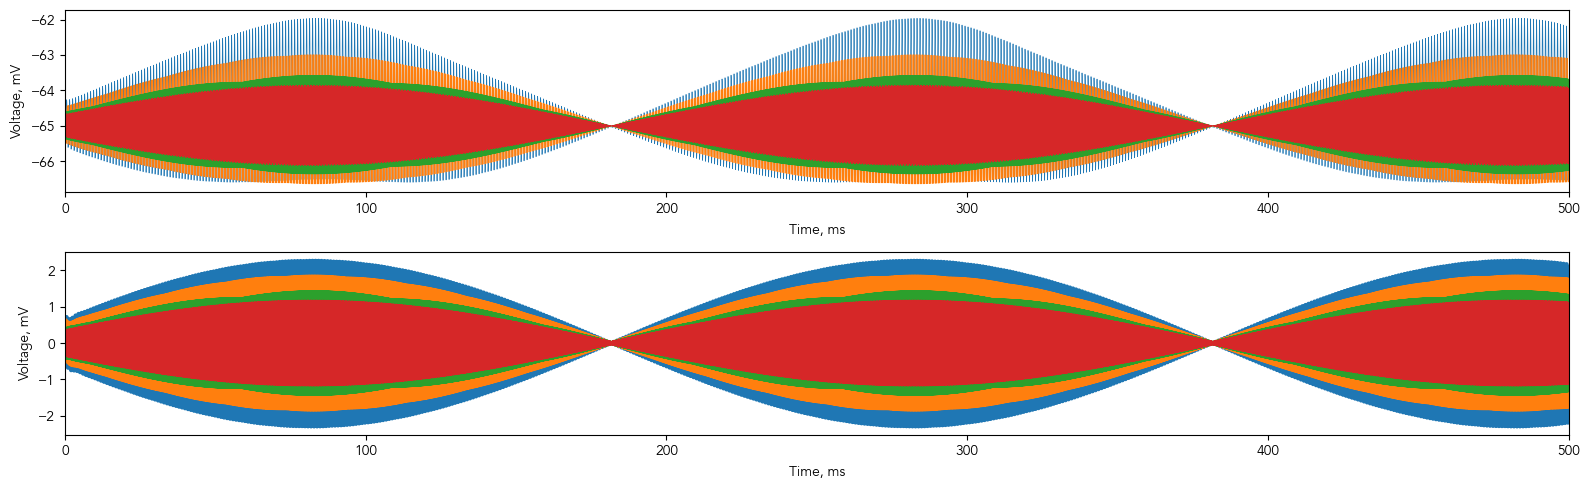

In [87]:
fig, axs = plt.subplots(nrows = 2, ncols = 1, figsize = (16, 2.5 * 2))

for carrier in carriers:
    voltage = pd.read_csv(f"output/temporal-interference/carrier_amplitude/{offset}/{carrier}_with_amplitude_of_{carrier_amplitude}.csv")

    axs[0].plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        label = "carrier"
    )

    axs[1].plot(
        voltage.Time,
        lowpass_filter(voltage.Voltage, fs = 1000 / voltage.Time[1], cutoff = 200),
        label = "carrier",
        linewidth = 3
    )

axs[0].set_ylabel("Voltage, mV")
axs[0].set_xlabel("Time, ms")
axs[0].set_xlim(0, 500)

axs[1].set_ylabel("Voltage, mV")
axs[1].set_xlabel("Time, ms")
axs[1].set_xlim(0, 500)

fig.tight_layout()
plt.show()